# Custom paddock boundaries

If you have field boundaries from QGIS, a cadastral layer, an earlier ground survey, or any other source, you can skip SAM segmentation and have PaddockTS run the per-paddock time series, plots, videos, and PDF report against *your* polygons.

Supported formats: GeoPackage (`.gpkg`), Shapefile (`.shp`), GeoJSON (`.geojson` / `.json`). The file just needs a polygon column; if a `paddock` column is missing, it's added as a 1-based integer ID. If `area_ha` or `compactness` are missing, they're computed from the geometry.

In [1]:
import geopandas as gpd

# This notebook uses the bundled artifact at the repo root. Replace with
# your own path to try on your data.
paddocks_fp = "../artifacts/PaddockSet1.gpkg"

paddocks = gpd.read_file(paddocks_fp)
print(f"{len(paddocks)} paddocks, columns: {list(paddocks.columns)}")
paddocks.head()

11 paddocks, columns: ['value', 'area_ha', 'compactness', 'paddock', 'geometry']


,value,area_ha,compactness,paddock,geometry
0,255.0,37.745229,0.691469,1,"POLYGON ((14316570 -4041960, 14316570 -4041970..."
1,255.0,35.225988,0.599704,2,"POLYGON ((14316130 -4041410, 14316130 -4041420..."
2,255.0,32.507040,0.505006,3,"POLYGON ((14316150 -4040490, 14316150 -4040500..."
3,255.0,26.989325,0.465924,4,"POLYGON ((14316860 -4040800, 14316860 -4040810..."
4,255.0,23.380562,0.322858,5,"POLYGON ((14314980 -4041290, 14314980 -4041340..."


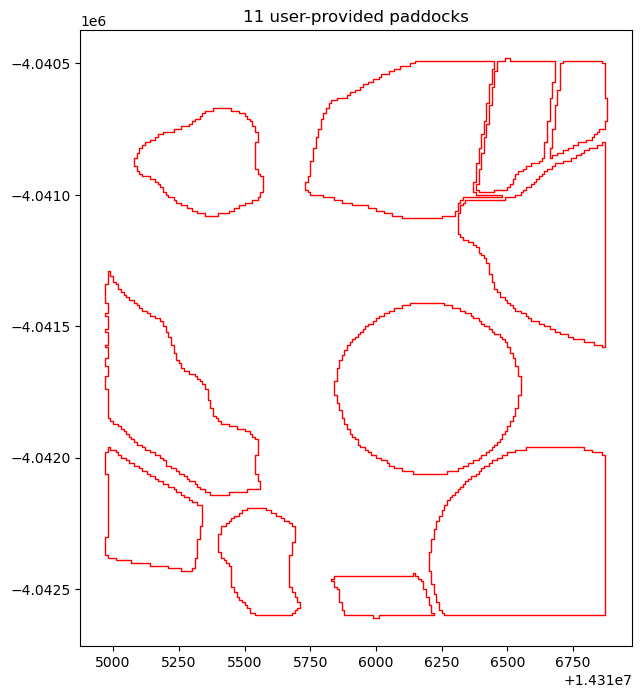

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
paddocks.plot(facecolor="none", edgecolor="red", linewidth=1, ax=ax)
ax.set_title(f"{len(paddocks)} user-provided paddocks")
ax.set_aspect("equal")
plt.show()

## Build a `Query` from the paddocks file

`Query.build_from_paddocks` takes the envelope of all paddock geometries as the AOI, so the Sentinel-2 download covers exactly the area you care about. The file is reprojected to EPSG:4326 if needed; the resulting bbox is `[W, S, E, N]` in decimal degrees.

Pass `label_col=` if your file has a human-readable name column you want surfaced in plots (instead of the numeric ID).

In [6]:
from datetime import date
from PaddockTS.query import Query

query = Query.build_from_paddocks(
    paddocks_filepath=paddocks_fp,
    start=date(2024, 1, 1),
    end=date(2024, 12, 31),
    stub="PaddockSet2",
    label_col="paddock", 
)
print(query)

-----  ---------------------------------------------------------------------------------
stub   PaddockSet2
bbox   [148.36275129247704, -33.526036421250936, 148.38254685299646, -33.50609210169209]
start  2024-01-01
end    2024-12-31
-----  ---------------------------------------------------------------------------------


## Run the full pipeline against your paddocks

Three things to pass through to `get_outputs`:

- `paddocks_filepath=` — the file to read.
- `skip_sam=True` — don't run SAM segmentation at all. Required if you only want user-paddock outputs.
- `label_col=` — column to use for paddock labels in calendars / videos / phenology plots. Defaults to the numeric `paddock` ID.

Or drop `skip_sam=True` to run **both** SAM and your paddocks side by side — useful for comparison. The PDF report then includes calendar + phenology sections for each.

In [7]:
from PaddockTS.get_outputs import get_outputs

get_outputs(
    query,
    paddocks_filepath=paddocks_fp,
    skip_sam=True,
    label_col="paddock",
)

Output()

## Where the outputs went

User-paddock outputs are keyed by the **paddocks file stem** (here `PaddockSet1`), not the SAM stem — so they don't collide with a SAM run on the same query.

In [8]:
from pathlib import Path

print(f"All outputs under {query.out_dir}:\n")
for p in sorted(Path(query.out_dir).iterdir()):
    print(f"  {p.name}")

All outputs under /Users/adeel/borevitz_projects/data/PaddockTSWeb/PaddockSet2:

  Environmental
  PaddockSet1_calendar_2024_p01.png
  PaddockSet1_fractional_cover_paddocks.mp4
  PaddockSet1_phenology_p01.png
  PaddockSet1_phenology_p02.png
  PaddockSet1_sentinel2_paddocks.mp4
  PaddockSet1_timeseries.zarr
  PaddockSet1_timeseries_2024.zarr
  PaddockSet2_fractional_cover.mp4
  PaddockSet2_ozwald_daily_precipitation.png
  PaddockSet2_ozwald_daily_radiation.png
  PaddockSet2_ozwald_daily_temperature.png
  PaddockSet2_ozwald_daily_wind.png
  PaddockSet2_report.pdf
  PaddockSet2_sentinel2.mp4
  PaddockSet2_silo_evapotranspiration.png
  PaddockSet2_silo_humidity.png
  PaddockSet2_silo_radiation.png
  PaddockSet2_silo_rainfall.png
  PaddockSet2_silo_temperature.png
  PaddockSet2_topography.png


## Direct call: skip the orchestrator entirely

Any individual stage accepts a `paddocks_filepath` argument so you can call it without `get_outputs`. The per-paddock TS, for example:

In [9]:
from PaddockTS.Phenology.make_paddock_time_series import make_paddock_time_series

ts = make_paddock_time_series(query, paddocks_filepath=paddocks_fp)
print(ts)

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Saved to /Users/adeel/borevitz_projects/data/PaddockTSWeb/PaddockSet2/PaddockSet1_timeseries.zarr
<xarray.Dataset> Size: 51kB
Dimensions:           (paddock: 11, time: 38)
Coordinates:
  * paddock           (paddock) <U2 88B '1' '2' '3' '4' ... '8' '9' '10' '11'
  * time              (time) datetime64[ns] 304B 2024-01-22T00:15:51.546810 ....
    spatial_ref       int32 4B 6933
Data variables: (12/15)
    CAI               (paddock, time) float64 3kB -0.1993 -0.3838 ... nan
    CFI               (paddock, time) float64 3kB 0.1113 0.09695 ... 0.08529 nan
    nbart_blue        (paddock, time) float64 3kB 298.0 321.0 ... 721.0 nan
    nbart_green       (paddock, time) float64 3kB 639.0 558.0 ... 988.0 nan
    nbart_nir_1       (paddock, time) float64 3kB 3.661e+03 5.171e+03 ... nan
    nbart_nir_2       (paddock, time) float64 3kB 3.802e+03 5.303e+03 ... nan
    ...                ...
    nbart_red_edge_3  (paddock, time) float64 3kB 3.494e+03 4.988e+03 ... nan
    nbart_swir_2      (paddo

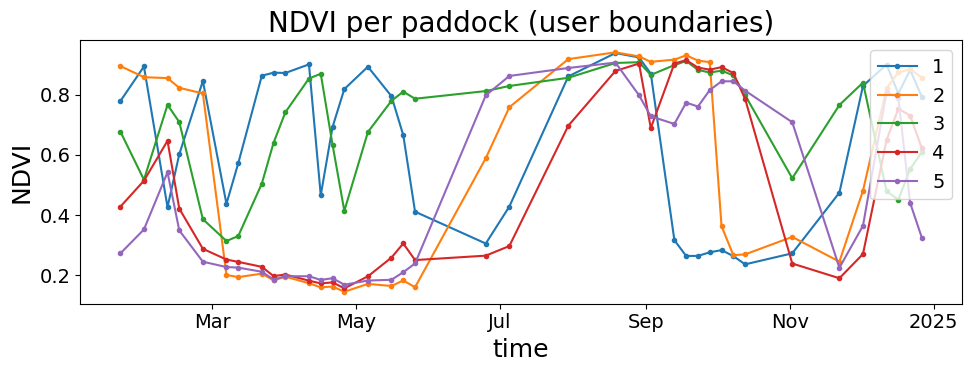

In [10]:
import io
import matplotlib.pyplot as plt
from IPython.display import Image as NBImage, display

# See note in cell 6 of demo/01_quickstart.ipynb: get_outputs forces matplotlib
# to the 'Agg' backend, which means `plt.show()` and `display(fig)` don't render
# inline. Render to a PNG buffer and display the bytes instead.
fig, ax = plt.subplots(figsize=(10, 4))
for p in ts.paddock.values[:5]:
    ts.NDVI.sel(paddock=p).plot(ax=ax, label=str(p), marker=".")
ax.set_title("NDVI per paddock (user boundaries)")
ax.set_ylabel("NDVI")
ax.legend(loc="upper right")
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
plt.close(fig)
display(NBImage(data=buf.getvalue()))


## See also

- [`01_quickstart.ipynb`](01_quickstart.ipynb) — auto-segmented (SAM) end-to-end.
- [`02_pipeline_stages.ipynb`](02_pipeline_stages.ipynb) — calling stages individually with explanations.
- [`Query.build_from_paddocks` docs](https://thestochasticman.github.io/paddock-ts-local/api/query/) — full constructor reference.